# **Redes Generativas Adversarias - GANs**

Las Redes Generativas Adversarias o GANs son un tipo de modelo generativo
introducido en 2014 muy poderoso para generar nuevos datos sintéticos, como imágenes, videos, o audio, que son casi indistinguibles de los datos reales.

Estas GANs se han vuelto esenciales para tareas que requieren la generación de
datos sintéticos realistas. Algunos casos útiles son:

- *Generación de imágenes realistas:*  Se utilizan para crear imágenes de alta calidad casi igual a fotos reales. Un ejemplo es *This Person Does Not Exist* (sitio web que genera caras realistas de personas que no existen).

- *Aumento de conjuntos de datos:*  En casos donde hay pocos datos, las GANs pueden generar datos adicionales para mejorar el entrenamiento de modelos supervisados.

- *Super-resolución de imágenes:* Pueden aumentar la resolución de imágenes de baja calidad mediante super-resolution GANs (SRGAN). Este proceso es útil en campos como la fotografía digital y la medicina.

Una **GAN** consta de dos redes neuronales que compiten entre sí en un
marco de aprendizaje. Estas redes son:


**Generador (Generator):**

El objetivo del generador es producir datos reales y generar ejemplos que parezcan suficientemente convincentes como para "engañar" al discriminador.

**Discriminador (Discriminator):**

En pocas palabras, el discriminador está diseñado como un clasificador binario (real o falso) que se entrena con ejemplos reales y generados.

---

Durante el entrenamiento, el **generador** intenta producir datos que el **discriminador** no pueda distinguir de los datos reales, mientras que el **discriminador** intenta mejorar su capacidad para diferenciar los datos reales de los falsos. En esencia, ambas redes compiten entre sí, este proceso lleva al **generador** a crear datos cada vez mejores con el tiempo.

## Implementación de GANs:

El siguiente código implementa una arquitectura GANs con un *generador* y un *discriminador* para generar imágenes falsas que se asemejan a los dígitos del conjunto de datos MNIST. El *generador* aprende a crear imágenes de aspecto realista, mientras que el *discriminador* aprende a distinguir entre imágenes reales y falsas. Durante el entrenamiento, tanto la red del *generador* como la del *discriminador* se actualizan iterativamente (7 epocas) hasta que el *generador* produce imágenes convincentes.

---

## Ejecución de codigo:

**1. Preparación de Datos (Dataset de imagenes)**

Conjunto de datos MNIST para generar imágenes falsas que sean similares a los dígitos.

**2. Ejecución de modelo Generador**

El modelo generador consta de una serie de capas densas y capas convolucionales transpuestas, el cual transforma la entrada de ruido en una imagen de 7x7 con 256 canales, luego aumenta la resolución de esta imagen hasta alcanzar un tamaño de 28x28, que es el tamaño de las imágenes MNIST.

**3. Ejecución de modelo Discriminador**

El modelo discriminador procesa las imágenes de entrada y las submuestrea gradualmente mediante capas convolucionales. La salida es un único valor que representa la probabilidad de que la entrada sea una imagen real (1) o falsa (0).

**4. Entrenamiento adversarial**

Se emplean funciones de pérdida para entrenar tanto al generador como al discriminador. La función de pérdida ayuda a ajustar los pesos de estos modelos durante el entrenamiento para optimizar su rendimiento, esto representa la naturaleza adversaria del entrenamiento de GAN.

**5. Ejecución de entrenamiento**

Se genera ruido aleatorio que se procesa mediante un generador para producir imágenes falsas. El discriminador evalúa tanto las imágenes reales como las falsas generadas por el generador. Se calculan los gradientes del generador y del discriminador en función de sus pérdidas, y sus parámetros se actualizan mediante el optimizador Adam.

**6. Visualización de epocas**

Se llama para cada lote de imágenes reales del conjunto de datos, durante un número específico de épocas. Al finalizar el cargue se imprimen los digitos generados.


***** REDES GENERATIVAS ADVERSARIAS - GANs **** 

Descarga de dataset - MNIST...
[Esta descarga puede tardar 20- 30 seg.]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Iniciando Época 1/7
Procesando lote 235/235Época 1 completada en 730.24 seg


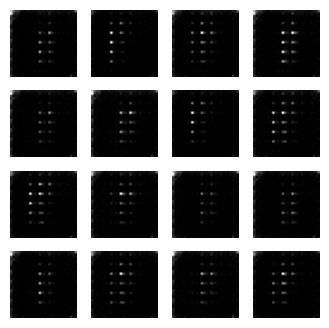


Iniciando Época 2/7
Procesando lote 235/235Época 2 completada en 741.91 seg


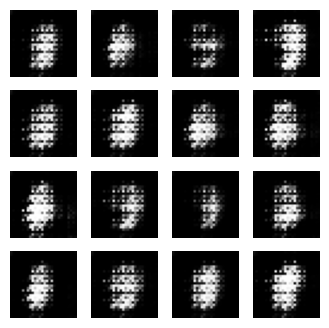


Iniciando Época 3/7
Procesando lote 235/235Época 3 completada en 673.73 seg


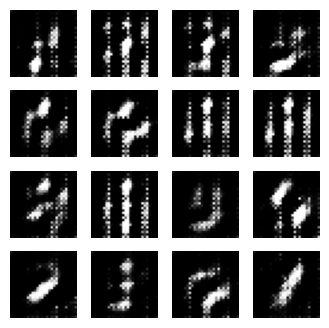


Iniciando Época 4/7
Procesando lote 235/235Época 4 completada en 689.87 seg


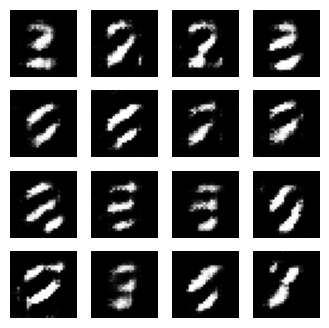


Iniciando Época 5/7
Procesando lote 235/235Época 5 completada en 697.14 seg


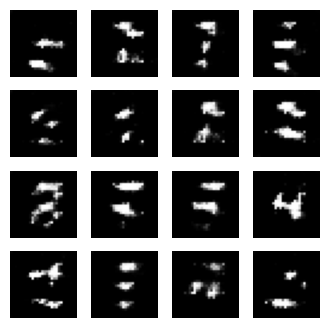


Iniciando Época 6/7
Procesando lote 235/235Época 6 completada en 668.91 seg


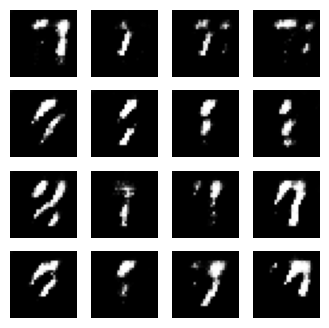


Iniciando Época 7/7
Procesando lote 235/235Época 7 completada en 680.50 seg


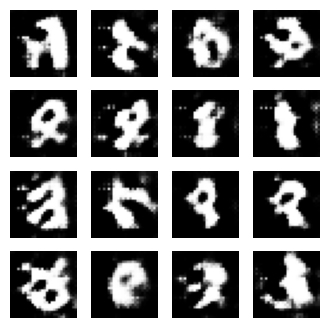

In [1]:
# ==============================================================================
# REDES GENERATIVAS ADVERSARIAS - GANs
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time
from IPython import display


print("***** REDES GENERATIVAS ADVERSARIAS - GANs **** \n")

# ---------------------------------------------------------
# 1. CARGA DEL MNIST Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
print("Descarga de dataset - MNIST...")
print("[Esta descarga puede tardar 20- 30 seg.]")

# Cargamos MNIST y normalizamos al rango [-1, 1]
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 256

# Creamos el pipeline de datos optimizado
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


# ---------------------------------------------------------
# 2. CONSTRUCCIÓN DEL MODELO - ARQUITECTURA GENERADOR/DISCRIMINADOR
# ---------------------------------------------------------

# Generador de datos falsos como entrada (semejantes a datos reales)
def build_generator():
    model = tf.keras.Sequential()

    # Definimos la entrada explícitamente (Vector de ruido de 100 dimensiones)
    model.add(layers.Input(shape=(100,)))

    model.add(layers.Dense(7*7*256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Remodelamos para iniciar las convoluciones transpuestas
    # (Toma 12,544 valores y los agrega en bloque 3D de 7x7 píxeles con 256 canales)
    model.add(layers.Reshape((7, 7, 256)))

    # Ampliacion de la imagen a 14x14
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Ampliacion de la imagen a 28x28
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Capa de salida: 28x28x1 con activación tanh
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model


# Clasificador binario que entrena con ejemplos reales y generados
def build_discriminator():
    model = tf.keras.Sequential()

    # Definimos la entrada explícitamente (Imágenes de 28x28x1)
    model.add(layers.Input(shape=(28, 28, 1)))

    #Extrae caracteristicas de imagen
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3)) #Apaga el 30% de datos de entrenamiento para que no memorice

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    # Salida sin activación (clasificador binario crudo)
    # Si el número es positivo, el modelo cree que la imagen es real, si es negativo cree que es falsa.
    model.add(layers.Dense(1))
    return model

generator = build_generator()
discriminator = build_discriminator()


# ---------------------------------------------------------
# 3. ENTRENAMIENTO ADVERSARIAL (PÉRDIDAS Y OPTIMIZADORES)
# ---------------------------------------------------------
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Se evalúa qué tanto se equivocó al clasificar las imágenes reales, y se evalua qué tanto se equivocó al clasificar las falsas.
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# Se invierte la lógica. El generador toma sus imágenes falsas y evalúa comparándolas contra imagen real
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


# ---------------------------------------------------------
# 4. ENTRENAMIENTO Y EVALUACIÓN
# ---------------------------------------------------------
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # El generador crea imágenes falsas
        generated_images = generator(noise, training=True)

        # El discriminador evalúa las reales y las falsas
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculamos el error de cada uno
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculamos los gradientes
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Aplicamos la optimización
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))


# ---------------------------------------------------------
# 5. ITERACION DE EPOCAS Y VISUALIZACIÓN
# ---------------------------------------------------------
def train(dataset, epochs):
    # Set para observar cómo el mismo ruido evoluciona época tras época
    seed = tf.random.normal([16, 100])
    total_batches = len(dataset)

    for epoch in range(epochs):
        start = time.time()
        print(f"\nIniciando Época {epoch + 1}/{epochs}")

        for batch_index, image_batch in enumerate(dataset):
            train_step(image_batch)
            # Indicador de progreso dinámico en la misma línea
            print(f"\rProcesando lote {batch_index + 1}/{total_batches}", end="", flush=True)

        print(f'Época {epoch + 1} completada en {time.time()-start:.2f} seg')

        # Generamos y visualizamos el grid de 4x4 imágenes
        predictions = generator(seed, training=False)
        fig = plt.figure(figsize=(4, 4))
        for i in range(predictions.shape[0]):
            plt.subplot(4, 4, i+1)
            plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
            plt.axis('off')
        plt.show()

# ---------------------------------------------------------
# 6. EJECUCIÓN DE MODELO
# ---------------------------------------------------------
EPOCHS = 7
train(train_dataset, EPOCHS)

## Conclusiones:
- Al ejecutar 7 épocas, las imágenes pasan de ser simple ruido a manchas grises con formas redondeadas que insinúan la anatomía de los dígitos, aunque aún borrosos e imperfectos.
- El mayor desafío al entrenar GANs es que ambos modelos deben aprender a un ritmo similar. Si el discriminador se vuelve demasiado preciso muy rápido, la función de pérdida devuelve un gradiente cercano a cero, y el generador deja de aprender.
- El generador es ciego a los datos originales. Nunca ve un dígito de MNIST. Toda la información de cómo estructurar los píxeles le llega indirectamente porel proceso de backpropagation, guiado por la probabilidad de error que comete el discriminador.
- En la época 5, el discriminador aún es un clasificador muy rudimentario. Todavía no sabe que un número debe tener bordes nítidos o trazos continuos.
- A medida que avanzan las épocas, el discriminador se vuelve un experto reconociendo bordes, forzando al generador a abandonar promedios borrosos y a comprometerse con trazados definidos y seguros para un solo dígito.